# 2st week's homework - by [Aleksei Novikov](https://www.linkedin.com/in/devnovikov/)

## Preparation

In [73]:
import pandas as pd
import numpy as np

import seaborn as sns

%matplotlib inline

## Data preparation

In [74]:
df = pd.read_csv("./car_fuel_efficiency.csv")

In [75]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
for col in list(df.dtypes[df.dtypes == 'object'].index):
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [76]:
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')

In [77]:
feature_columns = ['engine_displacement', 'horsepower', 'vehicle_weight' ,'model_year']
df[feature_columns]

,engine_displacement,horsepower,vehicle_weight,model_year
0,170,159.0,3413.433759,2003
1,130,97.0,3149.664934,2007
2,170,78.0,3079.038997,2018
3,220,NaN,2542.392402,2009
4,210,140.0,3460.870990,2009
...,...,...,...,...
9699,140,164.0,2981.107371,2013
9700,180,154.0,2439.525729,2004
9701,220,138.0,2583.471318,2008
9702,230,177.0,2905.527390,2011


### EDA

* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

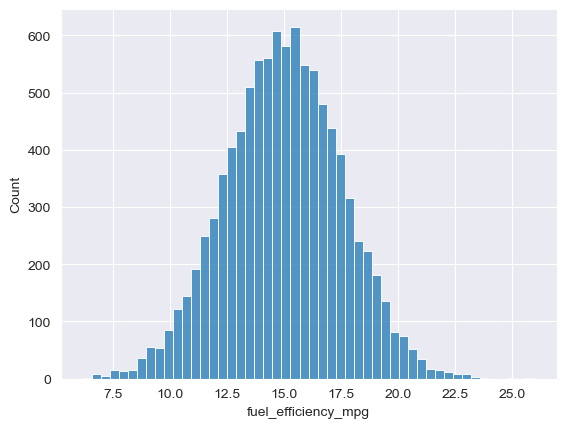

In [78]:
sns.histplot(df['fuel_efficiency_mpg'], bins=50)

In [79]:
df['fuel_efficiency_mpg'].skew()

np.float64(-0.012062219273507958)


* `fuel_efficiency_mpg` doesn't have a long tail. The variable has a skewness of approximately -0.012 and appears roughly normally distributed.

### Question 1

There's one column with missing values. What is it?
* `'horsepower'`

In [80]:
df[feature_columns].isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
dtype: int64

### Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 149

In [81]:
df['horsepower'].median()

149.0

### Prepare and split the dataset

* Shuffle the dataset (the filtered one you created above), use seed `42`.
* Split your data in train/val/test sets, with 60%/20%/20% distribution.

Use the same code as in the lectures

In [82]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [83]:
n, n_val, n_test, n_train

(9704, 1940, 1940, 5824)

In [84]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [85]:
df_train.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,220,3.0,144.0,2535.887591,18.7,2009,usa,gasoline,all-wheel_drive,2.0,16.642943
1,160,2.0,141.0,2741.170484,14.3,2019,asia,diesel,front-wheel_drive,2.0,16.298377
2,230,3.0,155.0,2471.880237,NaN,2017,asia,diesel,front-wheel_drive,2.0,18.591822
3,150,3.0,206.0,3748.164469,15.5,2015,usa,gasoline,all-wheel_drive,1.0,11.818843
4,300,4.0,111.0,2135.716359,16.9,2006,usa,gasoline,all-wheel_drive,NaN,19.402209


In [86]:
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [87]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

y_train,y_val,y_test

(array([16.64294342, 16.29837715, 18.59182197, ..., 17.59323665,
        18.92574819, 17.96528447]),
 array([15.36634109, 14.60118181, 12.24703219, ..., 13.61312692,
        13.73334321, 15.81604972]),
 array([15.80435416, 14.27237387, 11.74844072, ..., 18.40443466,
        20.50246014, 16.81624056]))

In [88]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 2 decimal digits using `round(score, 2)`
* Which option gives better RMSE?

Answer:

- With mean

In [89]:
def prepare_X_zero(df):
    df = df.copy()
    
    # Fill horsepower missing values with 0
    df_num = df[feature_columns].copy()
    df_num['horsepower'] = df_num['horsepower'].fillna(0)
    X = df_num.values

    return X

In [90]:
# Calculate mean on training data only (as per requirements)
mean_horsepower = df_train['horsepower'].mean()

def prepare_X_mean(df):
    df = df.copy()
    
    df_num = df[feature_columns].copy()
    df_num['horsepower'] = df_num['horsepower'].fillna(mean_horsepower)
    X = df_num.values

    return X

In [91]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [92]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [93]:
# №1: Fill with 0
X_train = prepare_X_zero(df_train)
X_val = prepare_X_zero(df_val)

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_val.dot(w)
score_zero = round(rmse(y_val, y_pred), 2)

print(f"RMSE with 0: {score_zero}")

# №2: Fill with mean
X_train = prepare_X_mean(df_train)
X_val = prepare_X_mean(df_val)

w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)
score_mean = round(rmse(y_val, y_pred), 2)

print(f"RMSE with mean: {score_mean}")

# Compare
if score_zero < score_mean:
    print("Answer: With 0")
elif score_mean < score_zero:
    print("Answer: With mean")
else:
    print("Answer: Both are equally good")

RMSE with 0: 0.52
RMSE with mean: 0.46
Answer: With mean


### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0.
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 2 decimal digits.
* Which `r` gives the best RMSE?

If there are multiple options, select the smallest `r`.

Answer:

- 0


In [94]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [95]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
scores = {}

for r in r_values:
    X_train = prepare_X_zero(df_train)
    X_val = prepare_X_zero(df_val)

    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    y_pred = w0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 2)
    scores[r] = score
    
    print(f"r = {r:>6}, RMSE = {score}")

best_r = min(scores, key=scores.get)
print(f"\nBest r: {best_r} with RMSE: {scores[best_r]}")

r =      0, RMSE = 0.52
r =   0.01, RMSE = 0.52
r =    0.1, RMSE = 0.52
r =      1, RMSE = 0.52
r =      5, RMSE = 0.52
r =     10, RMSE = 0.52
r =    100, RMSE = 0.52

Best r: 0 with RMSE: 0.52


### Question 5

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

Answer:
- 0.006

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different.
> If standard deviation of scores is low, then our model is *stable*.

In [96]:
seed_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []

for seed in seed_values:
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_train_seed = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val_seed = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)

    y_train_seed = df_train_seed.fuel_efficiency_mpg.values
    y_val_seed = df_val_seed.fuel_efficiency_mpg.values

    X_train_seed = prepare_X_zero(df_train_seed)
    X_val_seed = prepare_X_zero(df_val_seed)

    w0, w = train_linear_regression(X_train_seed, y_train_seed)

    y_pred = w0 + X_val_seed.dot(w)
    score = rmse(y_val_seed, y_pred)
    rmse_scores.append(score)

    print(f"Seed {seed}: RMSE = {score:.3f}")

std = np.std(rmse_scores)
print(f"Standard deviation: {round(std, 3)}")

Seed 0: RMSE = 0.521
Seed 1: RMSE = 0.521
Seed 2: RMSE = 0.523
Seed 3: RMSE = 0.516
Seed 4: RMSE = 0.511
Seed 5: RMSE = 0.528
Seed 6: RMSE = 0.531
Seed 7: RMSE = 0.509
Seed 8: RMSE = 0.515
Seed 9: RMSE = 0.513
Standard deviation: 0.007


### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`.
* What's the RMSE on the test dataset?

Answer:
- 0.515

In [98]:
seed = 9
idx = np.arange(n)
np.random.seed(seed)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values


X_full_train = prepare_X_zero(df_full_train)
y_full_train = np.concatenate([y_train, y_val])

X_test = prepare_X_zero(df_test)

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

print(f"Seed {seed}: RMSE = {score}")

Seed 9: RMSE = 0.5156261299162689
